# **Classification on Human Activity Recognition Using Smartphones Dataset with Bayesian Optimization**
## AI 221 Assignment 10

Submitted by: **Pangilinan, Reignel Bernice** 2018-01460 \\


Dataset reference: \\
[1] Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., & Parra, X. (2013). Human Activity Recognition Using Smartphones [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C54S4K.

\\

Code is loosely based on Dr. K. Pilario's work in https://github.com/kspilario/AI221/blob/main/Gaussian_Process%2BBayesOpt/BayesOpt_simple.ipynb


\\

Note: Before re-running the code, please make sure that the directories of the files containing the data is changed according to where the files are stored in your device.

\\

Disclaimer: The code in this notebook was written and debugged with the help of AI tools such as *Gemini* and *ChatGPT*.

## **Preliminaries**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np    # Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.pipeline import make_pipeline

import time

from warnings import filterwarnings
filterwarnings("ignore")

# Load the pre-split dataset (80-20 split)
path = r"/content/drive/My Drive/AI 221/assignment_09_dataset/"
X_train = pd.DataFrame(np.loadtxt(path + "X_train.txt"))   # Features in training set
X_test = pd.DataFrame(np.loadtxt(path + "X_test.txt"))   # Features in test set
y_train = pd.DataFrame(np.loadtxt(path + "y_train.txt"))   # Labels in training set
y_test = pd.DataFrame(np.loadtxt(path + "y_test.txt"))   # Labels in test set

print("========== TRAINING SET ==========")
display(pd.concat((X_train, y_train), axis = 1))

print("\n========== TEST SET ==========")
display(pd.concat((X_test, y_test), axis = 1))

========== TRAINING SET ==========


,0,1,2,3,4,5,6,7,8,9,...,552,553,554,555,556,557,558,559,560,0
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5.0
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5.0
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5.0
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5.0
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,2.0
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,2.0
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,2.0
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,2.0



========== TEST SET ==========


,0,1,2,3,4,5,6,7,8,9,...,552,553,554,555,556,557,558,559,560,0
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,5.0
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,5.0
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,5.0
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,5.0
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2.0
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2.0
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2.0
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,2.0


## **Exploratory Data Analysis (EDA)**

It is difficult to do other EDA tasks, such as obtaining the correlation matrix, on the dataset given the high number of features it contains so we are limited to understanding the descriptive statistics of the features instead. What we do know is that there are 6 classes, each corresponding to the following 6 activities: (1) walking, (2) walking upstairs, (3) walking downstairs, (4) sitting, (5) standing, (6) laying down. We assume that the encoded labels pertain to the mentioned activities in order.

In [ ]:
## Check the size of the dataframes (that the number of rows of the features agrees with the target's)
# Documentation says that there are no missing values in the dataset. We trust the authors on this.
print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")
print(f"y_train size: {y_train.shape}")
print(f"y_test size: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")


## Generate the descriptive statistics of each set
print("\nX_train descriptive statistics:")
display(X_train.describe())

print("\nX_test descriptive statistics:")
display(X_test.describe())


X_train size: (7352, 561)
X_test size: (2947, 561)
y_train size: (7352, 1)
y_test size: (2947, 1)
Number of classes: 6

X_train descriptive statistics:


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000



X_test descriptive statistics:


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,0.130236,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.231018,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-0.785543,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.008433,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,0.142676,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,0.288320,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113


In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE  # SMOTE for balancing data

## Check the distribution of the labels
class_counts = Counter(y_train.values.ravel())
print(f"Class Distribution before SMOTE: \n{class_counts}")

## To be sure, apply SMOTE to have a balanced dataset
smote = SMOTE(random_state = 42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f"\nClass Distribution after SMOTE: \n{Counter(y_train.values.ravel())}")

Class Distribution before SMOTE: 
Counter({np.float64(6.0): 1407, np.float64(5.0): 1374, np.float64(4.0): 1286, np.float64(1.0): 1226, np.float64(2.0): 1073, np.float64(3.0): 986})

Class Distribution after SMOTE: 
Counter({np.float64(5.0): 1407, np.float64(4.0): 1407, np.float64(6.0): 1407, np.float64(1.0): 1407, np.float64(3.0): 1407, np.float64(2.0): 1407})


## **Bayesian optimization to find the best hyperparameters**

As compared to the submitted work in Assignment 09, it is convenient to use the *torch* module and its packages to implement the fully-connected feed-forward neural network and the *BayesianOptimization* package of *bayes_opt* module to actually do the Bayesian optimization. In the previous assignment, *Tensorflow* ad *Keras* were used to implement the NN without any hyperparameter tuning. Here, we first need to install *bayesian-optimization* first before we can use it for our tasks.

In [ ]:
! pip install bayesian-optimization

Using Bayesian optimization, we want to tune the following parameters: learning rate of the feed-forward neural network, batch size (as we will employ mini-batch in the training of the NN), the number of neurons in the hidden layers, and the activation function to use in the hidden layer. For the activation function, we consider *ReLU*, *Tanh*, and *Sigmoid* functions.

In [ ]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as DataLoader
from sklearn.metrics import accuracy_score
from bayes_opt import BayesianOptimization

## Scale the dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values.ravel() - 1, dtype = torch.long)  # Change labels to 0-5 to match indexing
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values.ravel() - 1, dtype = torch.long)  # Change labels to 0-5 to mathc indexing


## Create PyTorch Dataset using DataLoader
train_dataset = DataLoader.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = DataLoader.TensorDataset(X_test_tensor, y_test_tensor)


## Dictionary of ativation functions and their keys
activation_functions = {0: nn.ReLU(),
                        1: nn.Tanh(),
                        2: nn.Sigmoid()}


## Define Feedforward Neural Network with tunable activation function, hidden layer size, learning rate, and batch size
class FeedForwardNN(nn.Module):   # Use torch to implement the neural network
  def __init__(self, input_size, hidden_size, output_size, activation_fn):
    super(FeedForwardNN, self).__init__()
    self.a1 = nn.Linear(input_size, hidden_size)
    self.activation = activation_fn
    self.a2 = nn.Linear(hidden_size, output_size)
    self.softmax = nn.Softmax(dim = 1)

  def forward(self, x):
    x = self.a1(x)
    x = self.activation(x)
    x = self.a2(x)
    return self.softmax(x)


## Function to train and evaluate the model
def Train_Evaluate(lr, batch_size, activation_index, hidden_size):
  batch_size = int(batch_size)    # Set batch size to integer
  activation_index = int(round(activation_index))   # Set key of activation function index to integer, rounded to match the index
  activation_fn = activation_functions[activation_index]    # Get the activation function using the key
  hidden_size = int(hidden_size)    # Set hidden layer size to integer

  # Create DataLoader for training
  train_loader = DataLoader.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)

  # Define model parameters
  input_size = X_train.shape[1]
  output_size = len(np.unique(y_train))  # Number of unique classes

  # Initialize model
  model = FeedForwardNN(input_size, hidden_size, output_size, activation_fn)
  criterion = nn.CrossEntropyLoss()   # Use cross entropy loss as evaluation for training
  optimizer = optim.Adam(model.parameters(), lr = lr) # Use adam to adjust the learning rate

  # Train for a few epochs
  epochs = 10
  model.train()
  for epoch in range(epochs):
    for inputs, labels in train_loader:
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

  # Evaluate on test set
  test_loader = DataLoader.DataLoader(test_dataset, batch_size = 64, shuffle = False)
  model.eval()
  all_preds, all_labels = [], []

  with torch.no_grad():
    for inputs, labels in test_loader:
      outputs = model(inputs)
      _, predicted = torch.max(outputs, 1)
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  accuracy = accuracy_score(all_labels, all_preds)
  return accuracy


## Define the Bayesian Optimization function
optimizer = BayesianOptimization(f = Train_Evaluate,
                                 pbounds = {"lr": (0.0001, 0.1),
                                            "batch_size": (16, 128),
                                            "activation_index": (0, 2),  # Activation function keys from the dict
                                            "hidden_size": (64, 256)},  # Hidden layer size range
                                 random_state = 21)


## Run the Bayesian Optimization process
optimizer.maximize(init_points = 5, n_iter = 15)


## Get the best hyperparameters
best_params = optimizer.max["params"]
best_lr = best_params["lr"]   # Get the best learning rate
best_batch_size = int(best_params["batch_size"])    # Get the best batch size
best_activation_fn = activation_functions[int(round(best_params["activation_index"]))]    # Get the best activation function
best_hidden_size = int(best_params["hidden_size"])  # Get the best hidden size

# Display the best parameters
print(f"\nBest Learning Rate: {best_lr}")
print(f"Best Batch Size: {best_batch_size}")
print(f"Best Activation Function: {best_activation_fn}")
print(f"Best Hidden Layer Size: {best_hidden_size}")


## Train final model with best hyperparameters
final_model = FeedForwardNN(X_train.shape[1], best_hidden_size, len(np.unique(y_train)), best_activation_fn)  # Use best_hidden_size
final_optimizer = optim.Adam(final_model.parameters(), lr = best_lr)

train_loader = DataLoader.DataLoader(train_dataset, batch_size = best_batch_size, shuffle = True)
criterion = nn.CrossEntropyLoss()


## Train final model to be used on the test set
epochs = 10
final_model.train()
for epoch in range(epochs):
  for inputs, labels in train_loader:
    final_optimizer.zero_grad()
    outputs = final_model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    final_optimizer.step()


## Evaluate final model on test set
final_model.eval()
test_loader = DataLoader.DataLoader(test_dataset, batch_size = 64, shuffle = False)
all_preds, all_labels = [], []

with torch.no_grad():
  for inputs, labels in test_loader:
    outputs = final_model(inputs)
    _, predicted = torch.max(outputs, 1)
    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

print(f"\nFinal Model Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

|   iter    |  target   | activa... | batch_... | hidden... |    lr     |
-------------------------------------------------------------------------
| 1         | 0.942     | 0.09745   | 48.38     | 202.4     | 0.002259  |
| 2         | 0.1683    | 0.4118    | 21.69     | 122.0     | 0.06642   |
| 3         | 0.4075    | 0.6162    | 81.36     | 77.36     | 0.08675   |
| 4         | 0.1822    | 0.2665    | 35.95     | 159.2     | 0.08638   |
| 5         | 0.6295    | 1.518     | 124.7     | 209.8     | 0.03849   |
| 6         | 0.3258    | 0.9409    | 48.45     | 202.3     | 0.08103   |
| 7         | 0.4771    | 1.78      | 126.0     | 232.8     | 0.04626   |
| 8         | 0.1683    | 0.1024    | 75.13     | 80.01     | 0.05009   |
| 9         | 0.3403    | 1.248     | 38.99     | 205.9     | 0.05097   |
| 10        | 0.9213    | 0.8566    | 85.56     | 110.2     | 0.01099   |
| 11        | 0.4886    | 0.6476    | 75.57     | 208.8     | 0.03146   |
| 12        | 0.772     | 1.962     | 

Since we have shifted the values of the labels so that the range would now be from 0 to 5 instead of 1 to 6, the following are the class labels: (0) walking, (1) walking upstairs, (2) walking downstairs, (3) sitting, (4) standing, (5) laying down. It still shows that the accuracy of the neural network model, though Bayesian optimization is applied, cannot beat that of the SVM model's used by the authors.

<Figure size 1000x1000 with 0 Axes>

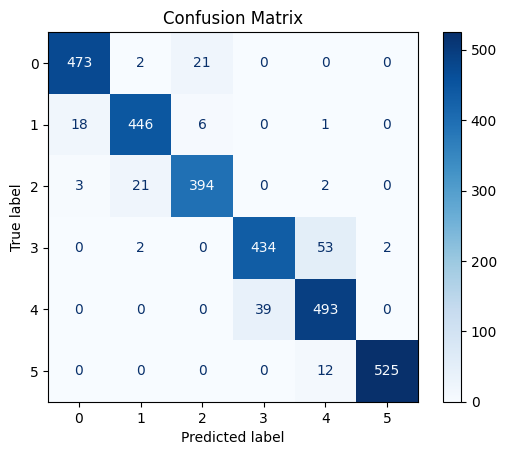

Classification report: 
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       496
           1       0.95      0.95      0.95       471
           2       0.94      0.94      0.94       420
           3       0.92      0.88      0.90       491
           4       0.88      0.93      0.90       532
           5       1.00      0.98      0.99       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(all_labels, all_preds)    # Generate the confusion matrix

plt.figure(figsize = (10, 10))
ConfusionMatrixDisplay(cm).plot(cmap = plt.cm.Blues)    # Display the confusion matrix
plt.title("Confusion Matrix")
plt.show()

print(f"Classification report: \n{classification_report(all_labels, all_preds)}") # Display the classification report

## **Conclusions**

Building on the results from the previous assignment, we have succesfully used Bayesian optimization for hyperparameter tuning in this assignment. Particularly, the following parameters of the fully-connected feed-forward neural network were tuned: the learning rate, batch size (considering mini-batch for training), number of neurons in the hidden layer, and the activation function for the hidden layer. After some test runs, *ReLU* as the activation function seem to be the best choice for the activation function.

If we assume that the following are the class labels: (0) walking, (1) walking upstairs, (2) walking downstairs, (3) sitting, (4) standing, and (5) laying down, similar to the previous assignment, the class STANDING is misclassified as SITTING the most. Again, the raw data of the signals (experiment itself can actually be viewed in the linked video in the repository) actually show that there is some similarity between the two so it should not be surprising that the model might confuse them. This is followed by class WALKING DOWNSTAIRS misclassified as WALKING UPSTAIRS. It might be that the signals do not capture the elevation so that these activities might appear similar to the model. Generally though, if we look at the misclassifications and the activities they pertain to, we should be able to realize that there are indeed similarities between such activities, practically speaking.